<a href="https://colab.research.google.com/github/dibaaminshahidi/ED-HGNN-ICU-LoS/blob/main/Ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [52]:
from pathlib import Path
import json
import pickle
import pandas as pd
import numpy as np


RESULTS_DIR = "/content/drive/MyDrive/Thesis/Results/CCI Removed"

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00


# Model Plot

In [ ]:
with open(f'{RESULTS_DIR}/Seed_87/Model/all_results.pkl', 'rb') as f:
    result = pickle.load(f)

train_losses = result['train_losses']
val_losses = result['val_losses']

### Learning Plots

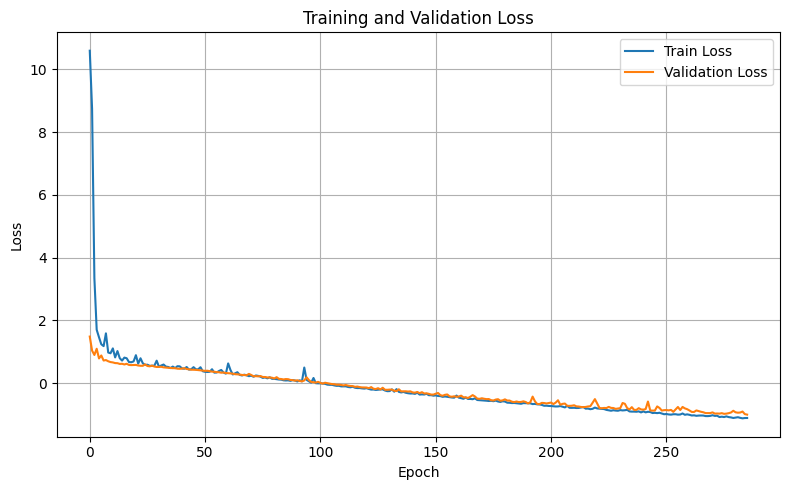

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_losses, label='Train Loss')
ax.plot(val_losses, label='Validation Loss')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/Plots/learning_curve.png', bbox_inches='tight')

plt.show()

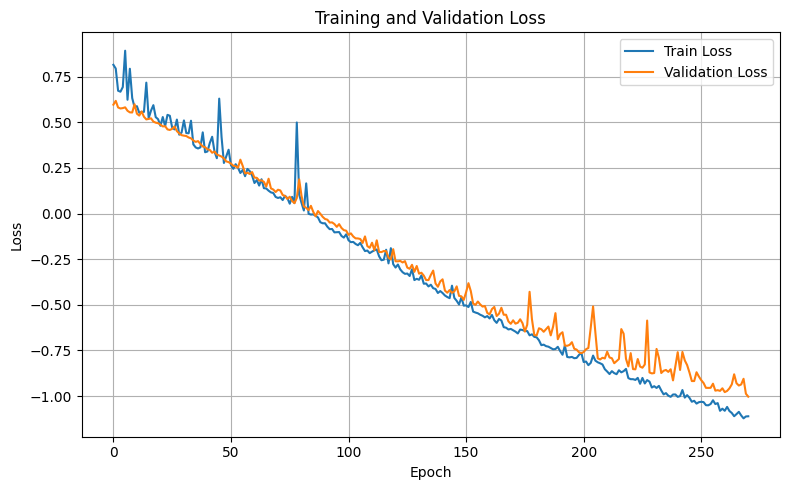

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

start_epoch = 15

ax.plot(train_losses[start_epoch:], label='Train Loss')
ax.plot(val_losses[start_epoch:], label='Validation Loss')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/Plots/learning_curve_cropped.png', bbox_inches='tight')

plt.show()

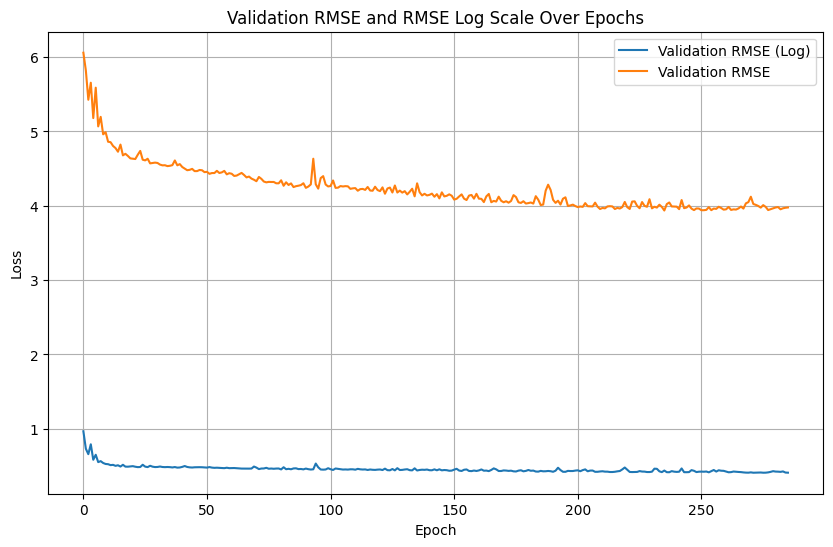

In [ ]:
import matplotlib.pyplot as plt

val_rmse_orig_scores = result['val_rmse_orig_scores']
val_rmse_log_scores = result['val_rmse_log_scores']
plt.figure(figsize=(10, 6))
plt.plot(val_rmse_log_scores, label='Validation RMSE (Log)')
plt.plot(val_rmse_orig_scores, label='Validation RMSE ')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation RMSE and RMSE Log Scale Over Epochs')
plt.legend()
plt.grid(True)
plt.savefig(f'{RESULTS_DIR}/Plots/learning_rmse.png', bbox_inches='tight')

plt.show()

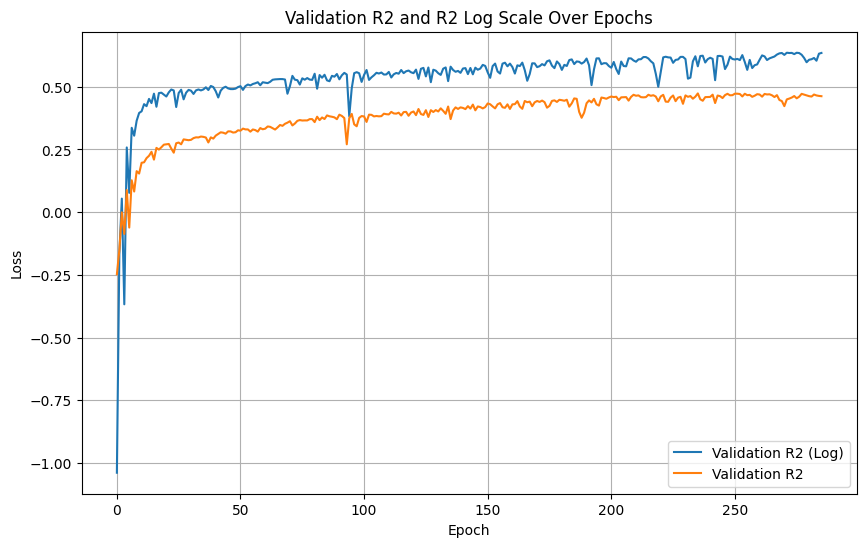

In [ ]:
val_r2_orig_scores = result['val_r2_orig_scores']
val_r2_scores = result['val_r2_scores']
plt.figure(figsize=(10, 6))
plt.plot(val_r2_scores, label='Validation R2 (Log)')
plt.plot(val_r2_orig_scores, label='Validation R2 ')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation R2 and R2 Log Scale Over Epochs')
plt.legend()
plt.grid(True)
plt.savefig(f'{RESULTS_DIR}/Plots/learning_r2.png', bbox_inches='tight')

plt.show()

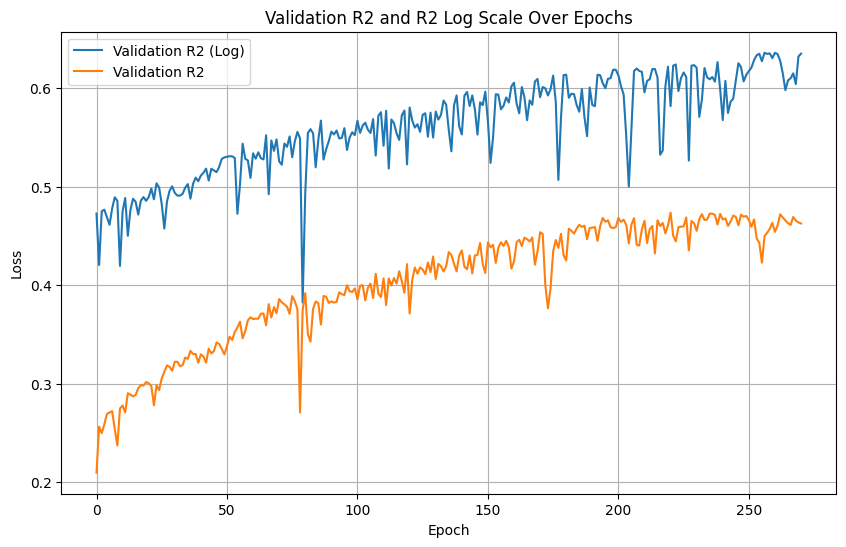

In [ ]:
start_epoch = 15

val_r2_orig_scores = result['val_r2_orig_scores']
val_r2_scores = result['val_r2_scores']
plt.figure(figsize=(10, 6))
plt.plot(val_r2_scores[start_epoch:], label='Validation R2 (Log)')
plt.plot(val_r2_orig_scores[start_epoch:], label='Validation R2 ')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation R2 and R2 Log Scale Over Epochs')
plt.legend()
plt.grid(True)
plt.savefig(f'{RESULTS_DIR}/Plots/learning_r2_cutted.png', bbox_inches='tight')

plt.show()

### Pred VS Actual

In [ ]:
with open(f'{RESULTS_DIR}/Seed_87/Model/test_results.pkl', 'rb') as f:
    result = pickle.load(f)
preds = result['preds']
targets = result['targets']

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

In [ ]:
preds = np.asarray(preds).flatten()
targets = np.asarray(targets).flatten()

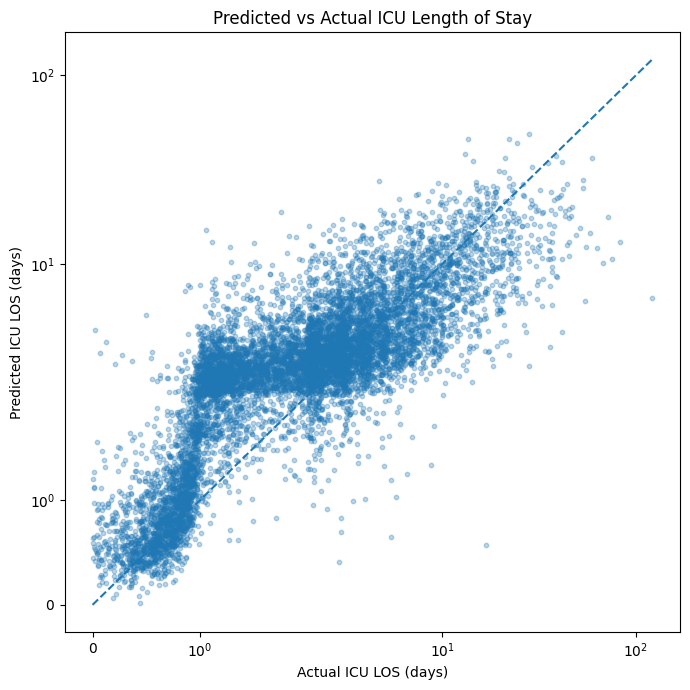

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(
    targets,
    preds,
    alpha=0.3,
    s=10
)

max_val = max(targets.max(), preds.max())

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle='--'
)
plt.xscale("symlog")
plt.yscale("symlog")

plt.xlabel("Actual ICU LOS (days)")
plt.ylabel("Predicted ICU LOS (days)")
plt.title("Predicted vs Actual ICU Length of Stay")

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/Plots/predicted_vs_actual_scale.png', bbox_inches='tight')

plt.show()


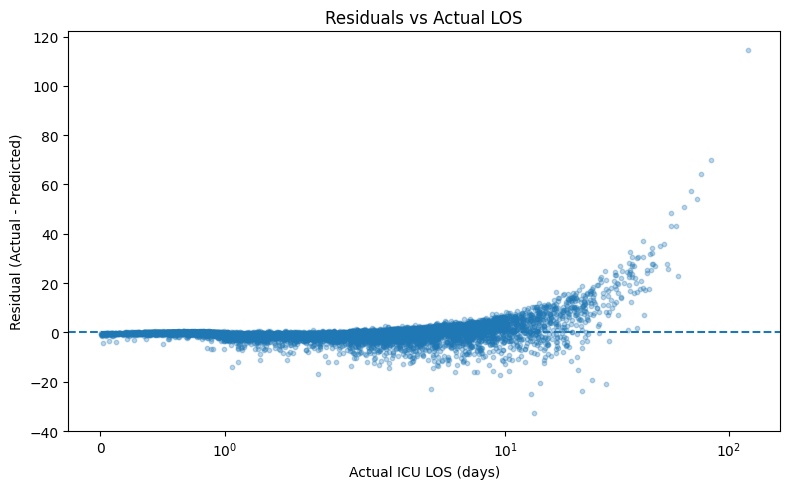

In [ ]:
residuals = targets - preds

plt.figure(figsize=(8,5))

plt.scatter(
    targets,
    residuals,
    alpha=0.3,
    s=10
)
plt.xscale("symlog")
# plt.yscale("symlog")
plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Actual ICU LOS (days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Actual LOS")


plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/Plots/residual_target_plots_scale.png', bbox_inches='tight')

plt.show()


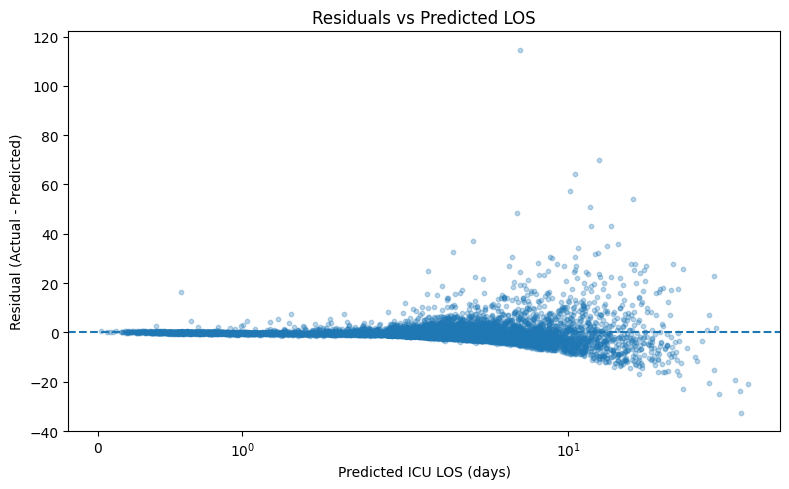

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    preds,
    residuals,
    alpha=0.3,
    s=10
)
plt.xscale("symlog")
# plt.yscale("symlog")
plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted ICU LOS (days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted LOS")

plt.savefig(f'{RESULTS_DIR}/Plots/residual_pred_plots_scale.png', bbox_inches='tight')

plt.tight_layout()
plt.show()

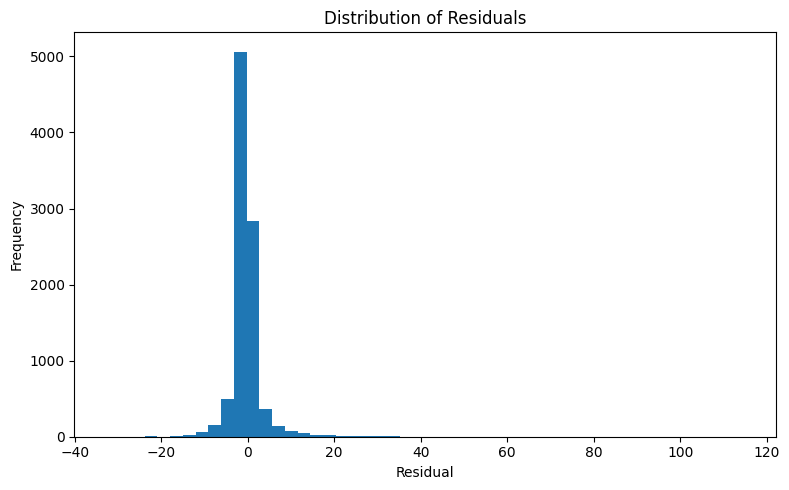

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=50
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/Plots/residual_histogram.png', bbox_inches='tight')

plt.tight_layout()
plt.show()



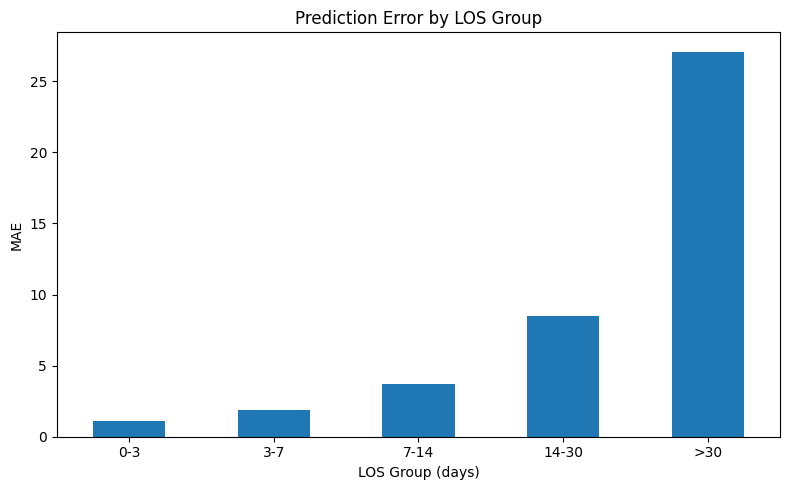

In [ ]:
BINS = [0, 3, 7, 14, 30, np.inf]
LABELS = [
    "0-3",
    "3-7",
    "7-14",
    "14-30",
    ">30"
]

df = pd.DataFrame({
    "target": targets,
    "pred": preds
})

df["group"] = pd.cut(
    df["target"],
    bins=BINS,
    labels=LABELS,
    include_lowest=True
)

group_mae = (
    df.groupby("group", observed=False)
      .agg(
          mae=("target", lambda x: mean_absolute_error(
              x,
              df.loc[x.index, "pred"]
          ))
      )["mae"]
)

plt.figure(figsize=(8,5))

group_mae.plot(
    kind='bar'
)

plt.ylabel("MAE")
plt.xlabel("LOS Group (days)")
plt.title("Prediction Error by LOS Group")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/Plots/error_by_LOS_group.png', bbox_inches='tight')

plt.show()


#Statistics

In [ ]:
import torch
from torch_geometric.data import HeteroData

dir = '/content/drive/MyDrive/Thesis/Codes/Data'
data = torch.load(f'{dir}/data_wo_cci.pt', weights_only=False)

In [ ]:
for node in data.node_types:
  print(f'{node}: Number of Nodes = {data[node].x.shape[0]} and Feature Dim = {data[node].x.shape[1]}')

stay: Number of Nodes = 94441 and Feature Dim = 25
patient: Number of Nodes = 223452 and Feature Dim = 2
diagnosis: Number of Nodes = 4945 and Feature Dim = 17
procedure: Number of Nodes = 110 and Feature Dim = 44
chart_numeric: Number of Nodes = 125 and Feature Dim = 36
input: Number of Nodes = 256 and Feature Dim = 46
output: Number of Nodes = 53 and Feature Dim = 50


In [ ]:
for edge in data.edge_types:
  print(f'{edge}: Number of Edges = {data[edge].edge_attr.shape[0]} and Edge Feature Dim = {data[edge].edge_attr.shape[1]}')

('patient', 'HAS_STAY', 'stay'): Number of Edges = 94501 and Edge Feature Dim = 53
('stay', 'HAS_DIAGNOSIS', 'diagnosis'): Number of Edges = 892471 and Edge Feature Dim = 65
('stay', 'HAS_PROCEDURE', 'procedure'): Number of Edges = 402453 and Edge Feature Dim = 19
('stay', 'HAS_CHARTED', 'chart_numeric'): Number of Edges = 1878607 and Edge Feature Dim = 16
('stay', 'HAS_INPUT', 'input'): Number of Edges = 881476 and Edge Feature Dim = 16
('stay', 'HAS_OUTPUT', 'output'): Number of Edges = 146442 and Edge Feature Dim = 13


## Los Dist

In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

In [ ]:
y_data = data['stay'].y.cpu().numpy() if isinstance(data['stay'].y, torch.Tensor) else data['stay'].y
log_y_data = data['stay'].log_y.cpu().numpy() if isinstance(data['stay'].log_y, torch.Tensor) else data['stay'].log_y

del data

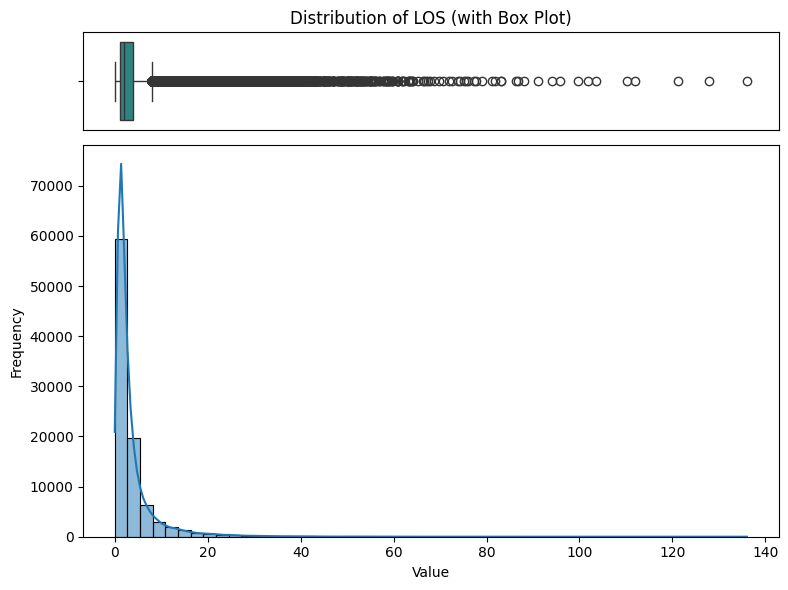

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

fig = plt.figure(figsize=(8, 6))
gs1 = fig.add_gridspec(2, 1, height_ratios=[0.2, 0.8])
ax_box1 = fig.add_subplot(gs1[0, 0])
ax_hist1 = fig.add_subplot(gs1[1, 0], sharex=ax_box1)

sns.boxplot(x=y_data, ax=ax_box1, palette='viridis')
ax_box1.set(xlabel='', yticklabels=[])
ax_box1.tick_params(axis='x', bottom=False)
ax_box1.set_title('Distribution of LOS (with Box Plot)')

sns.histplot(y_data, bins=50, kde=True, edgecolor='black', ax=ax_hist1, palette='viridis')
ax_hist1.set_xlabel('Value')
ax_hist1.set_ylabel('Frequency')

plt.setp(ax_box1.get_xticklabels(), visible=False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/Plots/los_distribution.png', bbox_inches='tight')
plt.show()

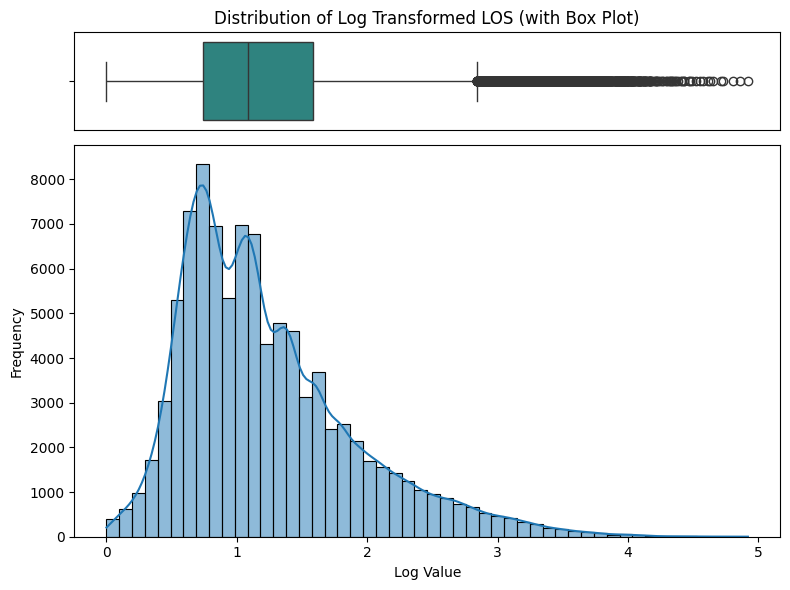

In [ ]:
fig = plt.figure(figsize=(8, 6))
gs2 = fig.add_gridspec(2, 1, height_ratios=[0.2, 0.8])
ax_box2 = fig.add_subplot(gs2[0, 0])
ax_hist2 = fig.add_subplot(gs2[1, 0], sharex=ax_box2)

sns.boxplot(x=log_y_data, ax=ax_box2, palette='viridis')
ax_box2.set(xlabel='', yticklabels=[])
ax_box2.tick_params(axis='x', bottom=False)
ax_box2.set_title('Distribution of Log Transformed LOS (with Box Plot)')

sns.histplot(log_y_data, bins=50, kde=True, edgecolor='black', ax=ax_hist2, palette='viridis')
ax_hist2.set_xlabel('Log Value')
ax_hist2.set_ylabel('Frequency')

plt.setp(ax_box2.get_xticklabels(), visible=False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/Plots/log_los_distribution.png', bbox_inches='tight')
plt.show()

#Ablation

## Baseline

In [ ]:
baseline_ablation_results = pd.read_csv(f'{RESULTS_DIR}/baseline_ablation_results_summary.csv'
)

In [ ]:
baseline_ablation_results = baseline_ablation_results.drop(columns= ['Unnamed: 0', 'Seed_mean',	'Seed_std'])

baseline_ablation_results

,Model,r2_log_mean,r2_log_std,mae_log_mean,mae_log_std,rmse_log_mean,rmse_log_std,r2_orig_mean,r2_orig_std,mae_orig_mean,mae_orig_std,rmse_orig_mean,rmse_orig_std
0,MLP,0.334529,0.051842,0.416680,0.016692,0.548053,0.019811,0.155708,0.058185,2.144005,0.063002,4.743458,0.137478
1,RandomForest,0.400467,0.007809,0.393936,0.002167,0.520542,0.003402,0.244438,0.014366,2.038155,0.032624,4.492614,0.180239
2,Ridge,0.452627,0.006518,0.379517,0.001306,0.497390,0.004033,0.313002,0.035216,1.971080,0.033423,4.282581,0.187408
3,XGBoost,0.467165,0.009779,0.374529,0.002820,0.490730,0.005152,0.312056,0.018538,1.937372,0.036136,4.287073,0.187401


## Read Full Mode (All Epochs)

In [ ]:
SEEDS = [7, 42, 12, 52, 87]

In [ ]:
full_mode_result = {}
for seed in SEEDS:
  with open(f'{RESULTS_DIR}/Seed_{seed}/Model/test_results.pkl', 'rb') as f:
    result = pickle.load(f)

  full_mode_result[f'seed_{seed}'] = result

In [ ]:
import pandas as pd

rows = []

for seed, vals in full_mode_result.items():
    row = {'seed': seed}

    for k, v in vals.items():
        if k not in ['preds', 'targets']:
            row[k] = float(v)

    rows.append(row)


df = pd.DataFrame(rows)

In [ ]:
df.describe()

,test_loss,r2,r2_orig,mae_log,mse_log,rmse_log,msle_val,mad_val,lmape,kappa,mae_orig,rmse_orig,kappa_binary
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,-0.934397,0.613593,0.446620,0.311627,0.174564,0.417699,0.182863,0.885078,37.023600,0.525284,1.825388,3.967225,0.533752
std,0.113148,0.016439,0.019018,0.013595,0.009041,0.010688,0.010002,0.077050,6.592624,0.012688,0.065833,0.183957,0.020695
min,-1.065313,0.586647,0.429359,0.299742,0.166646,0.408223,0.174143,0.825259,31.090456,0.509255,1.765542,3.771085,0.504526
25%,-0.971249,0.609438,0.431321,0.302676,0.169410,0.411594,0.178232,0.844146,33.599800,0.520552,1.801299,3.854317,0.527587
50%,-0.944020,0.620771,0.438810,0.308691,0.172706,0.415579,0.178919,0.844363,35.190861,0.520850,1.806581,3.909369,0.530174
75%,-0.937587,0.625471,0.462400,0.312867,0.174194,0.417366,0.183220,0.897375,37.097450,0.534170,1.815348,4.068565,0.548295
max,-0.753815,0.625638,0.471210,0.334159,0.189865,0.435735,0.199804,1.014245,48.139435,0.541593,1.938169,4.232790,0.558180


In [ ]:
df.to_csv(f'{RESULTS_DIR}/ED_HGNN_results.csv')

## Graph and Model

In [53]:
graph_ablation = [
    'Full',
    'Without edge attributes',
    'Without edge-to-node residual',
    'Without raw prediction branch'
    ]
rows = []
graph_models_result = {}
for model in graph_ablation:
  data = {}
  for seed in SEEDS:
    with open(f'{RESULTS_DIR}/Seed_{seed}/Graph Ablation/{model}/test_results.pkl', 'rb') as f:
      result = pickle.load(f)
    data[f'seed_{seed}'] = result
  graph_models_result[f'{model}'] = data


for model_name, seeds_dict in graph_models_result.items():
    for seed_name, metrics in seeds_dict.items():
        row = {
            "model": model_name,
            "seed": seed_name
        }
        for k, v in metrics.items():
            if k not in ["preds", "targets"]:
                try:
                    row[k] = float(v)
                except:
                    row[k] = v
        rows.append(row)
graph_models_df = pd.DataFrame(rows)

In [54]:
graph_edge_ablation = [
    "Without HAS_DIAGNOSIS",
    "Without HAS_PROCEDURE",
    "Without HAS_CHART",
    "Without HAS_INPUT",
    "Without HAS_OUTPUT",
    "No_INPUT_No_INPUT",
    "No_INPUT_No_INPUT_No_Chart",
    "Only_DIAGNOSIS",


    ]

graph_edge_result = {}
for edge in graph_edge_ablation:
  data = {}
  for seed in SEEDS[:-1]:
    with open(f'{RESULTS_DIR}/Seed_{seed}/Edges Ablation/{edge}/test_results.pkl', 'rb') as f:
      result = pickle.load(f)
    data[f'seed_{seed}'] = result
  graph_edge_result[f'{edge}'] = data

metric_names = [
    "test_loss",
    "r2",
    "r2_orig",
    "mae_log",
    "mse_log",
    "rmse_log",
    "msle_val",
    "mad_val",
    "lmape",
    "kappa",
    "mae_orig",
    "rmse_orig",
    "kappa_binary",
    "preds",
    "targets"
]

rows = []

for ablation_name, seeds_dict in graph_edge_result.items():
    for seed_name, values in seeds_dict.items():
        row = {
            "model": ablation_name,
            "seed": seed_name
        }
        for metric_name, value in zip(metric_names, values):
            if metric_name not in ["preds", "targets"]:
                try:
                    row[metric_name] = float(value)
                except:
                    row[metric_name] = value
        rows.append(row)

graph_edge_df = pd.DataFrame(rows)

In [57]:
ablation_reaslt = pd.concat([graph_models_df, graph_edge_df]).reset_index().drop(columns= ['index'])
ablation_reaslt.to_csv(f'{RESULTS_DIR}/ablation_results.csv')

numeric_cols = ablation_reaslt.select_dtypes(include='number').columns
summary = (
    ablation_reaslt.drop(columns = ['seed'])
    .groupby("model")
    .agg(['mean', 'std'])
    .round(4)
)
summary.to_csv(f'{RESULTS_DIR}/ablation_results_summary.csv')

In [58]:
import pandas as pd
import numpy as np

df_to_style = summary.copy()

# Flatten the MultiIndex columns from ('metric', 'agg_type') to 'metric_agg_type'
df_to_style.columns = ['_'.join(col).strip() for col in df_to_style.columns.values]

# The original code's manual column processing and slicing for 'Unnamed: 0'
# and iloc[2:] is not needed for the 'summary' DataFrame which already has
# a proper MultiIndex and index 'model'.


for col in df_to_style.columns:
    df_to_style[col] = pd.to_numeric(df_to_style[col], errors='coerce')

df_combined_display = pd.DataFrame(index=df_to_style.index)
mean_cols = [col for col in df_to_style.columns if col.endswith('_mean')]
min_max_values = {}

for mean_col in mean_cols:
    metric_name = mean_col.replace('_mean', '')
    std_col = f'{metric_name}_std'

    if std_col in df_to_style.columns:
        numeric_mean_series = df_to_style[mean_col]
        min_max_values[metric_name] = {
            'min': numeric_mean_series.min(),
            'max': numeric_mean_series.max()
        }

        df_combined_display[metric_name] = df_to_style.apply(
            lambda row: f"{row[mean_col]:.4f} \u00b1 {row[std_col]:.4f}"
            if pd.notna(row[mean_col]) and pd.notna(row[std_col])
            else '', axis=1
        )
    else:
        df_combined_display[metric_name] = df_to_style[mean_col].apply(
            lambda x: f"{x:.4f}" if pd.notna(x) else ''
        )

def highlight_min_max(cell_value, metric_name, min_max_data):
    if not isinstance(cell_value, str) or '±' not in cell_value:
        return ''

    try:
        mean_str = cell_value.split(' ')[0]
        numeric_mean = float(mean_str)

        if metric_name in min_max_data:
            if numeric_mean == min_max_data[metric_name]['max']:
                return 'background-color: yellow'
            elif numeric_mean == min_max_data[metric_name]['min']:
                return 'background-color: lightblue'
    except ValueError:
        pass
    return ''


In [59]:
df_combined_display[['r2',	'r2_orig',	'mae_log', 'rmse_log', 'mae_orig',	'rmse_orig']].sort_values('r2', ascending = False)

,r2,r2_orig,mae_log,rmse_log,mae_orig,rmse_orig
model,,,,,,
Without edge-to-node residual,0.6190 ± 0.0160,0.4030 ± 0.0140,0.2970 ± 0.0087,0.4147 ± 0.0066,1.7696 ± 0.0088,4.1202 ± 0.1658
Without HAS_OUTPUT,0.5944 ± 0.0140,0.4181 ± 0.0206,0.3190 ± 0.0084,0.4270 ± 0.0073,1.8363 ± 0.0340,4.0549 ± 0.1719
Without HAS_INPUT,0.5930 ± 0.0144,0.4296 ± 0.0186,0.3202 ± 0.0118,0.4278 ± 0.0076,1.8464 ± 0.0385,4.0161 ± 0.2104
Full,0.5709 ± 0.0507,0.4169 ± 0.0328,0.3333 ± 0.0274,0.4395 ± 0.0253,1.9005 ± 0.1005,4.0708 ± 0.1906
No_INPUT_No_INPUT,0.5691 ± 0.0213,0.3980 ± 0.0094,0.3344 ± 0.0139,0.4401 ± 0.0129,1.8965 ± 0.0647,4.1259 ± 0.1927
Without raw prediction branch,0.5665 ± 0.0329,0.4154 ± 0.0141,0.3372 ± 0.0203,0.4422 ± 0.0182,1.8682 ± 0.0954,4.0766 ± 0.1447
Without HAS_CHART,0.5468 ± 0.0248,0.4268 ± 0.0135,0.3462 ± 0.0132,0.4513 ± 0.0110,1.9140 ± 0.0755,4.0258 ± 0.1890
Without HAS_PROCEDURE,0.5393 ± 0.0216,0.4002 ± 0.0219,0.3424 ± 0.0131,0.4551 ± 0.0130,1.9325 ± 0.0782,4.1190 ± 0.2318
Without HAS_DIAGNOSIS,0.4612 ± 0.0187,0.2715 ± 0.0128,0.3800 ± 0.0117,0.4922 ± 0.0072,2.1463 ± 0.0450,4.5392 ± 0.2278
